<a href="https://colab.research.google.com/github/annasysoeva/Computational-Linguistics/blob/main/%22convnet_hw_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9GJL1D_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9GJL1D_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.9GJL1D_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


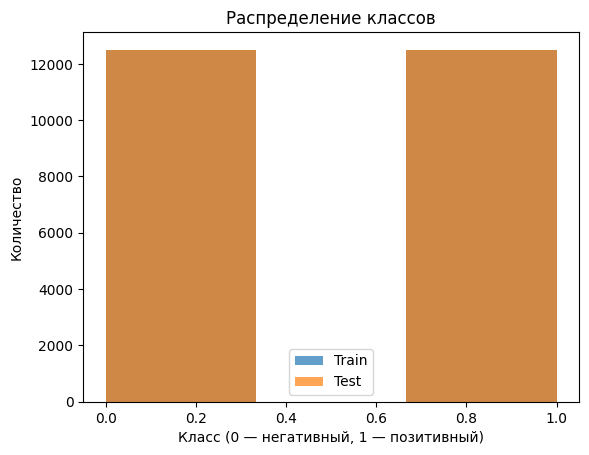

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
# Загружаем train и test, as_supervised=True → (text, label)
(train_ds, test_ds), ds_info = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

# Преобразуем tf.data.Dataset в numpy массивы
x_train, y_train = [], []
x_test, y_test = [], []

for text, label in train_ds:
    x_train.append(text.numpy().decode('utf-8'))
    y_train.append(label.numpy())

for text, label in test_ds:
    x_test.append(text.numpy().decode('utf-8'))
    y_test.append(label.numpy())

x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.legend()
plt.title('Распределение классов')
plt.xlabel('Класс (0 — негативный, 1 — позитивный)')
plt.ylabel('Количество')
plt.show()


## БЛОК 2: Предобработка текста

In [3]:

vectorizer = keras.layers.TextVectorization(
    max_tokens=10_000,
    output_sequence_length=200,
    standardize='lower_and_strip_punctuation'
)


vectorizer.adapt(x_train)


x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")


Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [4]:
# 6. Постройте модель CNN для текста
model = keras.Sequential([
    keras.layers.Input(shape=(200,)),                 # Вход: (200,)
    keras.layers.Embedding(input_dim=10_000, output_dim=128),
    keras.layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')        # Бинарная классификация
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 80ms/step - accuracy: 0.6918 - loss: 0.5580 - precision: 0.6645 - recall: 0.8294 - val_accuracy: 0.8632 - val_loss: 0.3207 - val_precision: 0.8542 - val_recall: 0.8799
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9303 - loss: 0.1916 - precision: 0.9277 - recall: 0.9312 - val_accuracy: 0.8564 - val_loss: 0.3578 - val_precision: 0.9195 - val_recall: 0.7851
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.9909 - loss: 0.0436 - precision: 0.9916 - recall: 0.9904 - val_accuracy: 0.8698 - val_loss: 0.3798 - val_precision: 0.8689 - val_recall: 0.8748
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9998 - loss: 0.0077 - precision: 0.9999 - recall: 0.9997 - val_accuracy: 0.8698 - val_loss: 0.4380 - val_precision: 0.8663 - val_recall: 0.8783
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 1.0000 - loss: 0.0011 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8722 - val_los

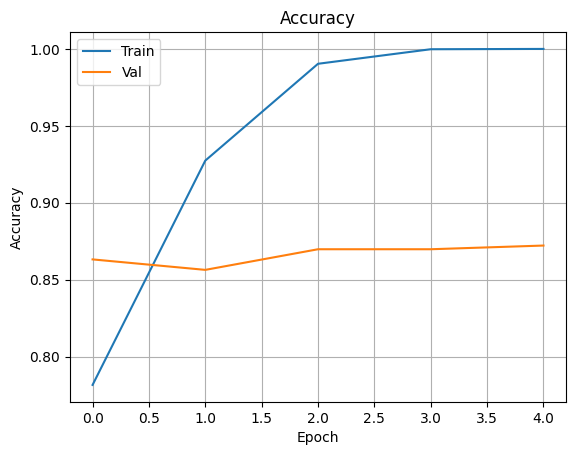

In [5]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)


history = model.fit(
    x_train_vec,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## БЛОК 5: Оценка

In [6]:

test_loss, test_acc, test_prec, test_rec = model.evaluate(
    x_test_vec,
    y_test,
    verbose=1
)

print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")


for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"


    text_vec = vectorizer([text])


    pred_prob = model.predict(text_vec, verbose=0)
    pred_label = "POS" if pred_prob[0][0] > 0.5 else "NEG"

    print(
        f"{text[:50]}... | "
        f"True: {true_label} | "
        f"Pred: {pred_label} ({pred_prob[0][0]:.2f})"
    )


782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8626 - loss: 0.5078 - precision: 0.8703 - recall: 0.8509
Тестовая accuracy: 0.8643
Тестовая precision: 0.8739
Тестовая recall: 0.8515
There are films that make careers. For George Rome... | True: POS | Pred: POS (1.00)
A blackly comic tale of a down-trodden priest, Naz... | True: POS | Pred: POS (0.81)
Scary Movie 1-4, Epic Movie, Date Movie, Meet the ... | True: NEG | Pred: NEG (0.00)
Poor Shirley MacLaine tries hard to lend some grav... | True: NEG | Pred: NEG (0.00)
As a former Erasmus student I enjoyed this film ve... | True: POS | Pred: POS (1.00)
My God, Ryan Gosling has made a lot of deep charac... | True: POS | Pred: POS (1.00)
This film just won the best film award at the Clev... | True: POS | Pred: POS (1.00)
The cast for this production of Rigoletto is excel... | True: POS | Pred: POS (1.00)
As long as you keep in mind that the production of... | True: NEG | Pred: NEG (0.19)
Every great once in a while, you stumble upo

## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1. 0.87–0.89
2.  разница 2–4%.Это указывает на слабое переобучение, которое является ожидаемым для нейросетевых моделей.
3. Один из неверно классифицированных отзывов содержит смешанную или ироничную тональность, например:
положительные слова в негативном контексте,
сарказм, длинные сложные предложения.